In [2]:
import os
import time
# import yaml
import numpy as np
from sciform import Formatter
# from scipy.stats import norm
# from scipy.stats import tstd
# from scipy import signal
# from statsmodels.stats.weightstats import DescrStatsW
import scared
from scared import aes
from scared.aes.selection_functions.encrypt import _add_round_key, _last_key
from pathlib import Path
import estraces
%matplotlib inline
import matplotlib.pyplot as plt
# import scalab
# from scalab import stat_measures as sm
# from scalab import dpacontest_v2 as dpac
# import pandas as pd

from io import BytesIO
import requests
from PIL import Image
from pathlib import Path
from PIL.PngImagePlugin import PngInfo

In [3]:
SAVE_PLOTS = False
DEBUG = True

In [6]:
def dpac_get_keys():
    key_strs = [
        "0000000000000003243F6A8885A308D3",
        "082EFA98EC4E6C89452821E638D01377",
        "0D95748F728EB658718BCD5882154AEE",
        "13198A2E03707344A4093822299F31D0",
        "21C66842F6E96C9A670C9C61ABD388F0",
        "23893E81D396ACC50F6D6FF383F44239",
        "24A19947B3916CF70801F2E2858EFC16",
        "2BA9C55D741831F6CE5C3E169B87931E",
        "2E0B4482A484200469C8F04A9E1F9B5E",
        "37D0D724D00A1248DB0FEAD349F1C09B",
        "3B8F48986B4BB9AFC4BFE81B66282193",
        "3F84D5B5B54709179216D5D98979FB1B",
        "4ED3AA62363F77061BFEDF72429B023D",
        "55CA396A2AAB10B6B4CC5C341141E8CE",
        "61D809CCFB21A991487CAC605DEC8032",
        "636920D871574E69A458FEA3F4933D7E",
        "6A51A0D2D8542F68960FA728AB5133A3",
        "6EEF0B6C137A3BE4BA3BF0507EFB2A98",
        "7B54A41DC25A59B59C30D5392AF26013",
        "8CEE8619456F9FB47D84A5C33B8B5EBE",
        "8E79DCB0603A180E6C9E0E8BB01E8A3E",
        "A15486AF7C72E993B3EE1411636FBC2A",
        "A1F1651D39AF017666CA593E82430E88",
        "AFD6BA336C24CF5C7A32538128958677",
        "B8E1AFED6A267E96BA7C9045F12C7F99",
        "BE5466CF34E90C6CC0AC29B7C97C50DD",
        "C5D1B023286085F0CA417918B8DB38EF",
        "D1310BA698DFB5AC2FFD72DBD01ADFB7",
        "D71577C1BD314B2778AF2FDA55605C60",
        "E06F75D885C12073401A449F56C16AA6",
        "E65525F3AA55AB945748986263E81440",
        "EF845D5DE98575B1DC262302EB651B88",
    ]

    return key_strs

### Helper functions

In [7]:
def ask_for_int(prompt, *, min_value=None, max_value=None):
    while True:
        user_input = input(prompt)

        try:
            value = int(user_input)
        except ValueError:
            print("Please enter a valid integer.")
            continue

        if min_value is not None and value < min_value:
            print(f"Please enter a value greater than or equal to {min_value}.")
            continue

        if max_value is not None and value > max_value:
            print(f"Please enter a value less than or equal to {max_value}.")
            continue

        return value

### Common formatter for reporting values in engineering notation

In [8]:
sform = Formatter(
    exp_mode="engineering",
    exp_format="prefix",     # uses e.g. M instead of e+06
    round_mode="dec_place",  # or "sig_fig" if we want to specify the total number of digits
    ndigits=3
)

# Students will select an image
They will input the image URL and the code will "force" the image to the correct format

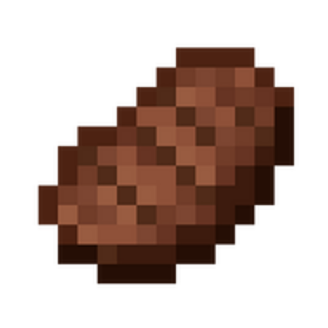

In [10]:
# Ask student for image URL
image_url = input("Paste the image URL here: ").strip()

# Download image
response = requests.get(image_url)
response.raise_for_status()

# Open image and force 3-channel RGB
img = Image.open(BytesIO(response.content)).convert("RGB")

# Optional: resize to keep encryption/decryption manageable
img = img.resize((256, 256))

# Convert to 256 x 256 x 3 NumPy array
img_array = np.asarray(img, dtype=np.uint8)

# Display image
plt.figure(figsize=(4, 4))
plt.imshow(img_array)
plt.axis("off")
plt.show()

### Students will choose a key to encrypt the image

In [11]:
key_strs = dpac_get_keys()

# This is where students will input the key number, 1 through 32, which they want to use
key_num = ask_for_int("Which key would you like to use (provide a number between 1 and 32):", min_value=1, max_value=32)
key_idx = key_num-1    # key_idx is zero indexed
key = np.frombuffer(bytes.fromhex(key_strs[key_idx]), dtype=np.uint8)

orig_shape = img_array.shape

# Flatten image to 1D bytes
img_flat = img_array.reshape(-1).astype(np.uint8)

# Check AES block alignment
if img_flat.size % 16 != 0:
    raise ValueError(f"Image byte length {img_flat.size} is not divisible by 16.")

# Reshape into N x 16 AES blocks
img_blocks = img_flat.reshape(-1, 16)

# ---------------------------------------------------------
# Placeholder for encryption step
# encrypted_flat = encrypt_function(img_flat)
# ---------------------------------------------------------
# encrypted_blocks = img_blocks    # encrypted_blocks has shape (N, 16)
encrypted_blocks = aes.encrypt(img_blocks, key)

# Reshape the encrypted image blocks
encrypted_flat = encrypted_blocks.reshape(-1)
encrypted_img_array = encrypted_flat.reshape(orig_shape)

# Create PNG metadata
metadata = PngInfo()
metadata.add_text("key_index", str(key_idx))

# Save encrypted image with metadata
encrypted_image_file = Path("encrypted_images", "team_1_A_encrypted.png")
img_to_save = Image.fromarray(encrypted_img_array, mode="RGB")
img_to_save.save(encrypted_image_file, pnginfo=metadata)

if DEBUG:
    print(f"key shape:", key.shape)
    print(f"key dtype:", key.dtype)
    print(f"The key used to encrypt the image is 0x{key_strs[key_idx]}")
    print("Original image shape:", orig_shape)
    print("Original image dtype:", img_array.dtype)
    print("Flattened shape:", img_flat.shape)
    print("AES block array shape:", img_blocks.shape)
    print("AES block array dtype:", img_blocks.dtype)
    print("Encrypted image shape:", encrypted_img_array.shape)
    print("Encrypted image dtype:", encrypted_img_array.dtype)
    print(f"Saved encrypted image to: {encrypted_image_file}")

key shape: (16,)
key dtype: uint8
The key used to encrypt the image is 0x0000000000000003243F6A8885A308D3
Original image shape: (256, 256, 3)
Original image dtype: uint8
Flattened shape: (196608,)
AES block array shape: (12288, 16)
AES block array dtype: uint8
Encrypted image shape: (256, 256, 3)
Encrypted image dtype: uint8
Saved encrypted image to: encrypted_images/team_1_A_encrypted.png


/tmp/ipykernel_11575/2393375800.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_to_save = Image.fromarray(encrypted_img_array, mode="RGB")


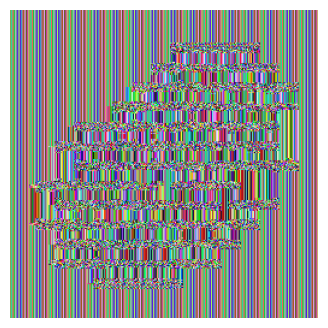

In [12]:
# Display image
plt.figure(figsize=(4, 4))
plt.imshow(encrypted_img_array)
plt.axis("off")
plt.show()

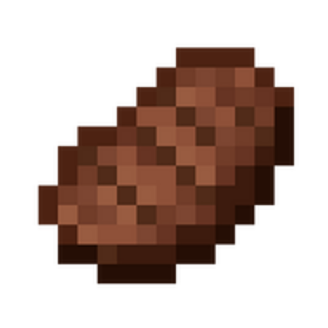

In [13]:
decrypted_blocks = aes.decrypt(encrypted_blocks, key)

# Reshape the encrypted image blocks
decrypted_flat = decrypted_blocks.reshape(-1)
decrypted_img_array = decrypted_flat.reshape(orig_shape)

# Display image
plt.figure(figsize=(4, 4))
plt.imshow(decrypted_img_array)
plt.axis("off")
plt.show()

In [14]:
print(key)

[  0   0   0   0   0   0   0   3  36  63 106 136 133 163   8 211]
